### Weekly Natural Gas Monitor — Next-Quarter Monte Carlo

> **Are U.S. natural gas conditions tightening or loosening over the next quarter, and is the move expected, elevated, or extreme?**

Core outputs:
- Historical storage and price-pressure monitor
- Supply vs demand diagnostics
- Balance chart
- Next-quarter Monte Carlo forecast with expected, min, max, and percentile bands
- Energy Atlas-style signal table for weekly reporting

Modeling note: this version treats price as a **storage-driven pressure index / price proxy**, not a precise Henry Hub point forecast. The goal is direction and extremeness, not exact price prediction.


In [1]:
# Imports

import random
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from calibration import calibrate_reference_scenario

from weather_data import (
    build_region_weather_monthly,
    merge_weather_into_monthly_panel,
    estimate_weather_demand_sensitivity,
)

## 1. Report configuration

In [2]:
# -----------------------------
# Weekly report settings
# -----------------------------

CALIBRATION_START = "2018-01"
CALIBRATION_END = None

REPORT_LOOKBACK_MONTHS = 36
FORECAST_MONTHS = 3
N_MONTE_CARLO = 500
MC_SEED = 42

REPORT_TITLE = "Natural Gas Weekly Monitor"
REPORT_DATE = pd.Timestamp.today().normalize()

# Forward Monte Carlo scenario assumptions
# These are broad scenario assumptions, not one-month hand tuning.
BASE_FORWARD = {
    "lng_export_pct": 0.00,
    "demand_sigma": 0.00,
    "supply_pct": 0.00,
    "pipeline_capacity_pct": 0.00,
}

COLD_LNG_FORWARD = {
    "lng_export_pct": 0.15,
    "demand_sigma": 1.00,
    "supply_pct": 0.00,
    "pipeline_capacity_pct": 0.00,
}

LOOSE_SUPPLY_FORWARD = {
    "lng_export_pct": 0.00,
    "demand_sigma": -0.50,
    "supply_pct": 0.03,
    "pipeline_capacity_pct": 0.00,
}

plt.rcParams["figure.figsize"] = (12, 5)


### Retrieve Region Weather Monthly data

In [3]:
weather_monthly = build_region_weather_monthly(
    stations_csv="major_airports_by_state_ghcnd.csv",
    region="all",
    start="2018-01-01",
    cache_dir="data/raw/noaa/stations",
)


## 2. Simulator core

The simulator has two modes:

### Historical backtest mode
Uses actual EIA monthly production, demand, LNG exports, and storage history to test whether the model captures broad physical dynamics.

### Forward simulation mode
Uses calibrated baseline parameters and random demand/weather variation to simulate next-quarter paths.

Price is represented as a **pressure proxy** derived from storage tightness and storage change.


In [4]:
DAYS_PER_MONTH = 30


class GasMarket:
    """
    Monthly natural gas balance simulator.

    Core identity:
        delivered_supply - demand = storage_change

    Price is not a recursive market-clearing forecast. It is a storage-driven
    pressure proxy used for trend direction and expected/elevated/extreme signals.
    """

    def __init__(self, scenario):
        self.scenario = scenario

        self.storage = float(scenario.get("initial_storage", 3000.0))
        self.storage_capacity = float(scenario.get("storage_capacity", 4200.0))
        self.max_injection = float(scenario.get("max_injection", 300.0))
        self.max_withdrawal = float(scenario.get("max_withdrawal", 500.0))

        self.base_price = float(scenario.get("base_price", 3.00))
        self.price = self.base_price

        self.history = []

    def _historical_row(self, month):
        """Return the row from a replay / forward panel if enabled."""
        if not self.scenario.get("use_historical_drivers", False):
            return None
        panel = self.scenario.get("historical_panel")
        if panel is None or month >= len(panel):
            return None
        return panel.iloc[month]

    def supply(self, month):
        row = self._historical_row(month)
        if row is not None and "production_bcf" in row and pd.notna(row["production_bcf"]):
            base_supply = float(row["production_bcf"])
        else:
            base_supply = float(self.scenario.get("base_supply", 3100.0))

        shock = float(self.scenario.get("supply_shock", 0.0))
        return max(0.0, base_supply + shock)

    def demand(self, month):
        """
        Demand = domestic demand + LNG exports.

        Priority order:
        1. If use_weather_demand=True and row has HDD/CDD, estimate demand from weather.
           This is the path used by forward Monte Carlo weather simulations.
        2. If replaying history and demand_bcf exists, use actual EIA demand.
        3. Fallback to seasonal demand plus optional random demand noise.
        """
        row = self._historical_row(month)
        use_weather = bool(self.scenario.get("use_weather_demand", False))

        # 1) Weather-driven demand. This MUST come before actual demand_bcf so
        # Monte Carlo weather paths are not ignored.
        if row is not None and use_weather and "hdd" in row and "cdd" in row:
            hdd = float(row["hdd"])
            cdd = float(row["cdd"])
            domestic_demand = (
                float(self.scenario.get("weather_base_demand", self.scenario.get("base_demand", 2900.0)))
                + float(self.scenario.get("hdd_sensitivity", 0.0)) * hdd
                + float(self.scenario.get("cdd_sensitivity", 0.0)) * cdd
                + float(self.scenario.get("weather_demand_bias_bcf", 0.0))
            )

            # Optional residual demand noise for Monte Carlo dispersion.
            noise_std = float(self.scenario.get("demand_noise_std", 0.0))
            if noise_std > 0:
                domestic_demand += np.random.normal(0.0, noise_std)

        # 2) Historical physical replay using actual EIA demand.
        elif row is not None and "demand_bcf" in row and pd.notna(row["demand_bcf"]):
            domestic_demand = float(row["demand_bcf"])

        # 3) Fallback forward mode when no weather panel is provided.
        else:
            base_demand = float(self.scenario.get("base_demand", 2900.0))
            seasonal_factors = self.scenario.get(
                "seasonal_factors",
                [1.35, 1.25, 1.05, 0.85, 0.75, 0.80, 0.95, 1.00, 0.85, 0.90, 1.05, 1.30],
            )
            raw_factor = float(seasonal_factors[month % 12])
            seasonal_strength = float(self.scenario.get("seasonal_strength", 1.0))
            seasonal_factor = 1.0 + seasonal_strength * (raw_factor - 1.0)

            weather_shock = random.gauss(
                float(self.scenario.get("weather_mean", 0.0)),
                float(self.scenario.get("weather_volatility", 80.0))
                * float(self.scenario.get("weather_volatility_scale", 1.0)),
            )

            noise_std = float(self.scenario.get("demand_noise_std", 0.0))
            domestic_demand = base_demand * seasonal_factor + weather_shock
            if noise_std > 0:
                domestic_demand += np.random.normal(0.0, noise_std)

        # LNG exports are part of total call on supply.
        if row is not None and "lng_exports_bcf" in row and pd.notna(row["lng_exports_bcf"]):
            lng_exports = float(row["lng_exports_bcf"])
        else:
            lng_exports = float(self.scenario.get("lng_exports", 400.0))

        return max(0.0, domestic_demand + lng_exports)

    def pipeline_constraint(self, raw_supply):
        pipeline_capacity = float(self.scenario.get("pipeline_capacity", 3400.0))
        return min(raw_supply, pipeline_capacity)

    def estimate_price_pressure(self, storage_change):
        """
        Price-pressure proxy.

        This is not intended as a precise Henry Hub forecast. It measures
        directional pressure from inventory tightness and storage flows.
        """
        base_price = float(self.scenario.get("base_price", 3.00))
        storage_ratio = self.storage / self.storage_capacity if self.storage_capacity > 0 else 0.5

        target_ratio = float(self.scenario.get("target_storage_ratio", 0.55))
        storage_tightness = target_ratio - storage_ratio

        storage_sensitivity = float(self.scenario.get("storage_price_sensitivity", 2.0))
        flow_sensitivity = float(self.scenario.get("storage_change_price_sensitivity", 0.001))

        raw_price = base_price + storage_sensitivity * storage_tightness - flow_sensitivity * storage_change

        inertia = float(self.scenario.get("price_inertia", 0.65))
        estimated_price = inertia * self.price + (1.0 - inertia) * raw_price

        price_floor = float(self.scenario.get("price_floor", 0.50))
        price_cap = float(self.scenario.get("price_cap", 12.00))

        return max(price_floor, min(price_cap, estimated_price))

    def monthly_step(self, month):
        storage_start = self.storage

        raw_supply = self.supply(month)
        delivered_supply = self.pipeline_constraint(raw_supply)
        demand = self.demand(month)
        balance = delivered_supply - demand

        if balance > 0:
            storage_change = min(balance, self.storage_capacity - self.storage, self.max_injection)
        else:
            storage_change = -min(-balance, self.storage, self.max_withdrawal)

        self.storage += storage_change
        self.price = self.estimate_price_pressure(storage_change)

        storage_ratio = self.storage / self.storage_capacity if self.storage_capacity > 0 else np.nan

        self.history.append({
            "month": month + 1,
            "price": round(self.price, 3),
            "raw_supply_bcf": round(raw_supply, 1),
            "delivered_supply_bcf": round(delivered_supply, 1),
            "demand_bcf": round(demand, 1),
            "balance_bcf": round(balance, 1),
            "storage_start_bcf": round(storage_start, 1),
            "storage_bcf": round(self.storage, 1),
            "storage_change_bcf": round(storage_change, 1),
            "storage_ratio": round(storage_ratio, 3),
            "pipeline_capacity_bcf": self.scenario.get("pipeline_capacity", 3400.0),
            "lng_exports_bcf": self.scenario.get("lng_exports", 400.0),
        })


def run_scenario(name, scenario, months=24, seed=42):
    random.seed(seed)
    np.random.seed(seed)

    market = GasMarket(scenario)
    for month in range(months):
        market.monthly_step(month)

    df = pd.DataFrame(market.history)
    df["scenario"] = name
    return df


## 3. Load EIA data and calibrate baseline scenario

This uses your `calibration.py` file, which calls your EIA natural gas data retrieval layer and returns:

1. `base_scenario` — simulator-ready parameters
2. `monthly_df` — cleaned monthly EIA history


In [5]:
base_scenario, monthly_df = calibrate_reference_scenario(
    start=CALIBRATION_START,
    end=CALIBRATION_END,
)

monthly_df = monthly_df.copy()
monthly_df.index = pd.to_datetime(monthly_df.index)

print(monthly_df.tail())
print("\nCalibrated baseline scenario keys:")
print(sorted(base_scenario.keys()))


            production_bcf  demand_bcf  industrial_demand_bcf  storage_bcf  \
2025-10-01        3327.295    2443.231              610.80775         3905   
2025-11-01        3308.316    2782.526              695.63150         3913   
2025-12-01        3460.493    3498.325              874.58125         3364   
2026-01-01        3363.241    3785.289              946.32225         2454   
2026-02-01        3080.138    3109.686              777.42150         1876   

            lng_exports_bcf  henry_hub_price  storage_change_bcf  
2025-10-01          503.520         3.199091               354.0  
2025-11-01          525.089         3.794118                 8.0  
2025-12-01          569.267         4.263810              -549.0  
2026-01-01          539.203         7.717895              -910.0  
2026-02-01          493.617         3.621579              -578.0  

Calibrated baseline scenario keys:
['base_demand', 'base_price', 'base_supply', 'calibration_config', 'calibration_end', 'calibr

### Add Monthly Weather to Reference Scenario

In [6]:
monthly_with_weather = merge_weather_into_monthly_panel(
    monthly_df,
    weather_monthly,
    region="lower_48",
)

monthly_with_weather = monthly_with_weather.copy()
monthly_with_weather.index = pd.to_datetime(monthly_with_weather.index)
monthly_with_weather = monthly_with_weather.sort_index()

# Use only weather columns as the Monte Carlo source. The full monthly_with_weather
# panel is for calibration/backtesting; weather_df is for future weather paths.
weather_df = monthly_with_weather[["hdd", "cdd"]].dropna().copy()

weather_params = estimate_weather_demand_sensitivity(monthly_with_weather)
base_scenario.update(weather_params)

print("Weather parameters:")
print(weather_params)
print("\nWeather source preview:")
print(weather_df.tail())


Weather parameters:
{'demand_intercept_bcf': 1973.6704691632453, 'hdd_sensitivity_bcf_per_hdd': 1.5964047955698881, 'cdd_sensitivity_bcf_per_cdd': 1.3016509675482009, 'weather_model_residual_std_bcf': 152.3032388645085, 'weather_model_r2': 0.8785205220355682}

Weather source preview:
                hdd     cdd
date                       
2025-10-01  171.450  33.285
2025-11-01  493.245   0.000
2025-12-01  813.480   0.000
2026-01-01  993.390   0.000
2026-02-01  697.650   0.000


### Demand vs weather diagnostics

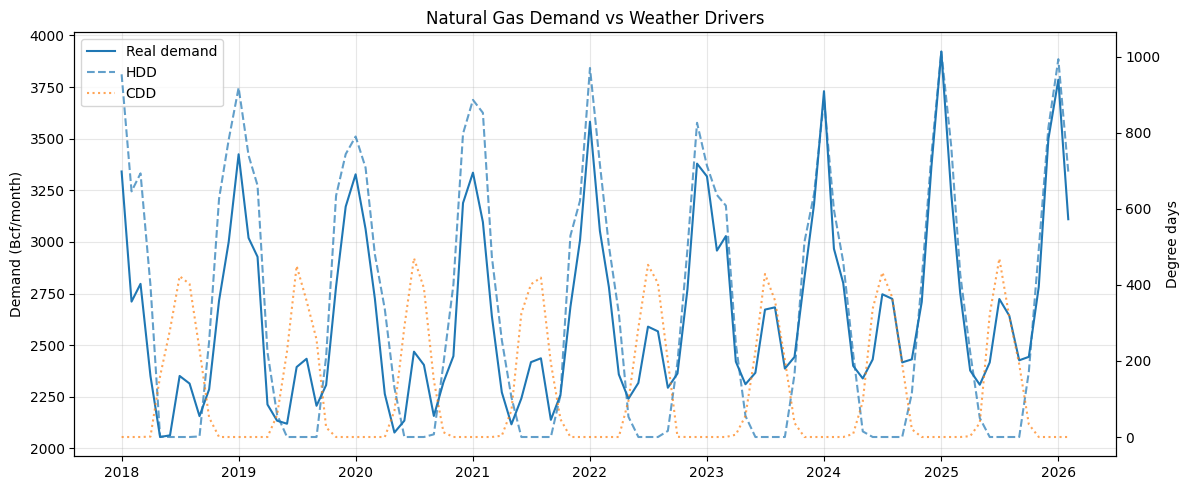

In [7]:
def plot_demand_vs_weather(monthly_with_weather):
    df = monthly_with_weather.copy()
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()

    fig, ax1 = plt.subplots(figsize=(12, 5))
    ax1.plot(df.index, df["demand_bcf"], label="Real demand")
    ax1.set_ylabel("Demand (Bcf/month)")
    ax1.set_title("Natural Gas Demand vs Weather Drivers")
    ax1.grid(True, alpha=0.3)

    ax2 = ax1.twinx()
    ax2.plot(df.index, df["hdd"], linestyle="--", alpha=0.7, label="HDD")
    ax2.plot(df.index, df["cdd"], linestyle=":", alpha=0.7, label="CDD")
    ax2.set_ylabel("Degree days")

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
    plt.tight_layout()
    plt.show()


plot_demand_vs_weather(monthly_with_weather)


## 4. Scenario builders

These helper functions keep historical backtests, reporting charts, and forward Monte Carlo forecasts separate.


In [8]:
def make_backtest_scenario(base_scenario, monthly_df):
    s = base_scenario.copy()

    # Replay actual EIA drivers month-by-month.
    s["use_historical_drivers"] = True
    s["historical_panel"] = monthly_df.copy()
    s["use_weather_demand"] = False

    # Start from the first historical storage value for clean backtest comparison.
    s["initial_storage"] = float(monthly_df["storage_bcf"].iloc[0])

    # No random weather noise during historical replay.
    s["weather_mean"] = 0.0
    s["weather_volatility"] = 0.0
    s["weather_volatility_scale"] = 0.0
    s["demand_noise_std"] = 0.0

    # General pressure model defaults.
    s["target_storage_ratio"] = 0.55
    s["storage_price_sensitivity"] = 2.0
    s["storage_change_price_sensitivity"] = 0.001
    s["price_inertia"] = 0.65
    s["seasonal_strength"] = 0.90

    return s


def make_forward_scenario(
    base_scenario,
    *,
    initial_storage,
    lng_export_pct=0.0,
    demand_sigma=0.0,
    supply_pct=0.0,
    pipeline_capacity_pct=0.0,
    weather_volatility_scale=1.0,
):
    s = base_scenario.copy()

    # Forward mode will receive a generated weather panel in the Monte Carlo step.
    s["use_historical_drivers"] = False
    s["use_weather_demand"] = False
    s.pop("historical_panel", None)

    s["initial_storage"] = float(initial_storage)
    s["lng_exports"] = float(s["lng_exports"] * (1.0 + lng_export_pct))
    s["base_supply"] = float(s["base_supply"] * (1.0 + supply_pct))
    s["pipeline_capacity"] = float(s["pipeline_capacity"] * (1.0 + pipeline_capacity_pct))

    # demand_sigma is a structural demand bias in units of calibrated residual volatility.
    demand_bias = float(demand_sigma * s.get("weather_volatility", 0.0))
    s["base_demand"] = float(s["base_demand"] + demand_bias)
    s["weather_demand_bias_bcf"] = float(s.get("weather_demand_bias_bcf", 0.0) + demand_bias)

    # General pressure model defaults. These may be overwritten by grid search later.
    s["target_storage_ratio"] = 0.55
    s["storage_price_sensitivity"] = 2.0
    s["storage_change_price_sensitivity"] = 0.001
    s["price_inertia"] = 0.65
    s["seasonal_strength"] = 0.90
    s["weather_volatility_scale"] = weather_volatility_scale

    return s


def build_comparison(monthly_df, simulated):
    historical = monthly_df.copy()
    historical = historical.reset_index().rename(columns={"index": "date"})
    historical["month"] = range(1, len(historical) + 1)

    comparison = historical.merge(simulated, on="month", suffixes=("_real", "_sim"))

    rename_map = {
        "henry_hub_price": "price_real",
        "price": "price_pressure_sim",

        "storage_bcf_real": "storage_real",
        "storage_bcf_sim": "storage_end_sim",
        "storage_bcf_x": "storage_real",
        "storage_bcf_y": "storage_end_sim",

        "storage_change_bcf_real": "storage_change_real",
        "storage_change_bcf_sim": "storage_change_sim",
        "storage_change_bcf_x": "storage_change_real",
        "storage_change_bcf_y": "storage_change_sim",

        "demand_bcf_real": "demand_real",
        "demand_bcf_sim": "demand_sim",
        "demand_bcf_x": "demand_real",
        "demand_bcf_y": "demand_sim",

        "production_bcf": "supply_real",
        "raw_supply_bcf": "supply_sim",
    }

    comparison = comparison.rename(columns={
        old: new for old, new in rename_map.items() if old in comparison.columns
    })

    return comparison


def get_recent_window(df, months=36):
    return df.tail(months).copy()


## 5. Historical backtest

This tests whether the model captures broad historical storage and pressure behavior.

Do not overfit this section to one month. Use the full-period scores and charts.


In [9]:
backtest_scenario = make_backtest_scenario(base_scenario, monthly_df)
simulated = run_scenario("Backtest", backtest_scenario, months=len(monthly_df), seed=MC_SEED)
comparison = build_comparison(monthly_df, simulated)

comparison[[
    "date",
    "price_real",
    "price_pressure_sim",
    "storage_real",
    "storage_start_bcf",
    "storage_end_sim",
    "storage_change_real",
    "storage_change_sim",
]].tail(12)


,date,price_real,price_pressure_sim,storage_real,storage_start_bcf,storage_end_sim,storage_change_real,storage_change_sim
86,2025-03-01,4.120000,3.526,1773,1721.1,1839.1,13.0,118.1
87,2025-04-01,3.423333,3.318,2041,1839.1,2220.9,268.0,381.7
88,2025-05-01,3.118571,3.023,2598,2220.9,2777.9,557.0,557.0
89,2025-06-01,3.024000,2.813,2953,2777.9,3181.7,355.0,403.9
90,2025-07-01,3.201364,2.729,3123,3181.7,3349.4,170.0,167.7
91,2025-08-01,2.912857,2.611,3262,3349.4,3582.7,139.0,233.2
92,2025-09-01,2.974286,2.427,3551,3582.7,3939.0,289.0,356.3
93,2025-10-01,3.199091,2.432,3905,3939.0,3939.0,354.0,0.0
94,2025-11-01,3.794118,2.436,3913,3939.0,3939.0,8.0,0.0
95,2025-12-01,4.263810,2.829,3364,3939.0,3198.3,-549.0,-740.7


## 6. Backtest scoring

Useful diagnostics:
- Storage MAE — how close inventory path is
- Storage-change MAE — how close monthly builds/draws are
- Storage-change directional accuracy — whether the model gets build/draw direction right
- Price-pressure directional accuracy — whether pressure direction matches Henry Hub monthly direction


In [10]:
def score_backtest(comparison):
    df = comparison.copy()

    df["storage_error"] = df["storage_end_sim"] - df["storage_real"]
    df["storage_change_error"] = df["storage_change_sim"] - df["storage_change_real"]

    storage_mae = df["storage_error"].abs().mean()
    storage_change_mae = df["storage_change_error"].abs().mean()

    valid_storage_change = df.dropna(subset=["storage_change_real", "storage_change_sim"])
    storage_direction_accuracy = (
        np.sign(valid_storage_change["storage_change_real"]) == np.sign(valid_storage_change["storage_change_sim"])
    ).mean()

    df["real_price_change"] = df["price_real"].diff()
    df["sim_pressure_change"] = df["price_pressure_sim"].diff()
    valid_price = df.dropna(subset=["real_price_change", "sim_pressure_change"])
    price_direction_accuracy = (
        np.sign(valid_price["real_price_change"]) == np.sign(valid_price["sim_pressure_change"])
    ).mean()

    return {
        "storage_mae_bcf": round(float(storage_mae), 1),
        "storage_change_mae_bcf": round(float(storage_change_mae), 1),
        "storage_change_direction_accuracy": round(float(storage_direction_accuracy), 3),
        "price_pressure_direction_accuracy": round(float(price_direction_accuracy), 3),
    }

score_backtest(comparison)


{'storage_mae_bcf': 423.5,
 'storage_change_mae_bcf': 75.5,
 'storage_change_direction_accuracy': 0.928,
 'price_pressure_direction_accuracy': 0.464}

## 7. Tune global pressure parameters

This grid search tunes only global pressure parameters.

It does **not** tune individual months. That keeps the model general enough for weekly monitoring.


In [11]:
def evaluate_pressure_params(base_scenario, monthly_df, storage_sens, flow_sens, inertia):
    s = make_backtest_scenario(base_scenario, monthly_df)
    s["storage_price_sensitivity"] = storage_sens
    s["storage_change_price_sensitivity"] = flow_sens
    s["price_inertia"] = inertia

    sim = run_scenario("Backtest", s, months=len(monthly_df), seed=MC_SEED)
    comp = build_comparison(monthly_df, sim)
    scores = score_backtest(comp)

    # Lower is better. Prioritize storage fit and price direction rather than exact price level.
    objective = (
        scores["storage_mae_bcf"]
        + 0.50 * scores["storage_change_mae_bcf"]
        - 100.0 * scores["price_pressure_direction_accuracy"]
        - 75.0 * scores["storage_change_direction_accuracy"]
    )

    return {
        "storage_price_sensitivity": storage_sens,
        "storage_change_price_sensitivity": flow_sens,
        "price_inertia": inertia,
        "objective": objective,
        **scores,
    }


grid_rows = []
for storage_sens in [1.0, 1.5, 2.0, 2.5, 3.0]:
    for flow_sens in [0.0005, 0.0010, 0.0015, 0.0020]:
        for inertia in [0.50, 0.65, 0.80]:
            grid_rows.append(evaluate_pressure_params(base_scenario, monthly_df, storage_sens, flow_sens, inertia))

grid_df = pd.DataFrame(grid_rows).sort_values("objective")
grid_df.head(10)


,storage_price_sensitivity,storage_change_price_sensitivity,price_inertia,objective,storage_mae_bcf,storage_change_mae_bcf,storage_change_direction_accuracy,price_pressure_direction_accuracy
6,1.0,0.0015,0.50,343.15,423.5,75.5,0.928,0.485
11,1.0,0.0020,0.80,343.15,423.5,75.5,0.928,0.485
12,1.5,0.0005,0.50,343.15,423.5,75.5,0.928,0.485
21,1.5,0.0020,0.50,343.15,423.5,75.5,0.928,0.485
51,3.0,0.0010,0.50,343.15,423.5,75.5,0.928,0.485
43,2.5,0.0015,0.65,343.15,423.5,75.5,0.928,0.485
8,1.0,0.0015,0.80,344.25,423.5,75.5,0.928,0.474
23,1.5,0.0020,0.80,344.25,423.5,75.5,0.928,0.474
18,1.5,0.0015,0.50,344.25,423.5,75.5,0.928,0.474
31,2.0,0.0015,0.65,344.25,423.5,75.5,0.928,0.474


## 8. Final historical monitor using best global parameters

This becomes the main historical dataframe used for weekly charts.


In [12]:
best = grid_df.iloc[0].to_dict()
print(best)

best_scenario = make_backtest_scenario(base_scenario, monthly_df)
best_scenario["storage_price_sensitivity"] = best["storage_price_sensitivity"]
best_scenario["storage_change_price_sensitivity"] = best["storage_change_price_sensitivity"]
best_scenario["price_inertia"] = best["price_inertia"]

best_simulated = run_scenario("Best Backtest", best_scenario, months=len(monthly_df), seed=MC_SEED)
best_comparison = build_comparison(monthly_df, best_simulated)

score_backtest(best_comparison)


{'storage_price_sensitivity': 1.0, 'storage_change_price_sensitivity': 0.0015, 'price_inertia': 0.5, 'objective': 343.15, 'storage_mae_bcf': 423.5, 'storage_change_mae_bcf': 75.5, 'storage_change_direction_accuracy': 0.928, 'price_pressure_direction_accuracy': 0.485}


{'storage_mae_bcf': 423.5,
 'storage_change_mae_bcf': 75.5,
 'storage_change_direction_accuracy': 0.928,
 'price_pressure_direction_accuracy': 0.485}

## 9. Reporting window

All weekly charts use the most recent `REPORT_LOOKBACK_MONTHS` months to keep the report readable.


In [13]:
report_df = get_recent_window(best_comparison, months=REPORT_LOOKBACK_MONTHS)

print("Report window:", report_df["date"].min().date(), "to", report_df["date"].max().date())
report_df.tail()


Report window: 2023-03-01 to 2026-02-01


,date,supply_real,demand_real,industrial_demand_bcf,storage_real,lng_exports_bcf_real,price_real,storage_change_real,month,price_pressure_sim,...,delivered_supply_bcf,demand_sim,balance_bcf,storage_start_bcf,storage_end_sim,storage_change_sim,storage_ratio,pipeline_capacity_bcf,lng_exports_bcf_sim,scenario
93,2025-10-01,3327.295,2443.231,610.80775,3905,503.520,3.199091,354.0,94,2.704,...,3326.9,2946.8,380.2,3939.0,3939.0,0.0,1.000,3326.9329,285.411051,Best Backtest
94,2025-11-01,3308.316,2782.526,695.63150,3913,525.089,3.794118,8.0,95,2.798,...,3308.3,3307.6,0.7,3939.0,3939.0,0.0,1.000,3326.9329,285.411051,Best Backtest
95,2025-12-01,3460.493,3498.325,874.58125,3364,569.267,4.263810,-549.0,96,3.495,...,3326.9,4067.6,-740.7,3939.0,3198.3,-740.7,0.812,3326.9329,285.411051,Best Backtest
96,2026-01-01,3363.241,3785.289,946.32225,2454,539.203,7.717895,-910.0,97,4.162,...,3326.9,4324.5,-997.6,3198.3,2200.8,-997.6,0.559,3326.9329,285.411051,Best Backtest
97,2026-02-01,3080.138,3109.686,777.42150,1876,493.617,3.621579,-578.0,98,4.207,...,3080.1,3603.3,-523.2,2200.8,1677.6,-523.2,0.426,3326.9329,285.411051,Best Backtest


## 10. Weekly chart pack — storage and price pressure

Use these as your core weekly monitoring charts.


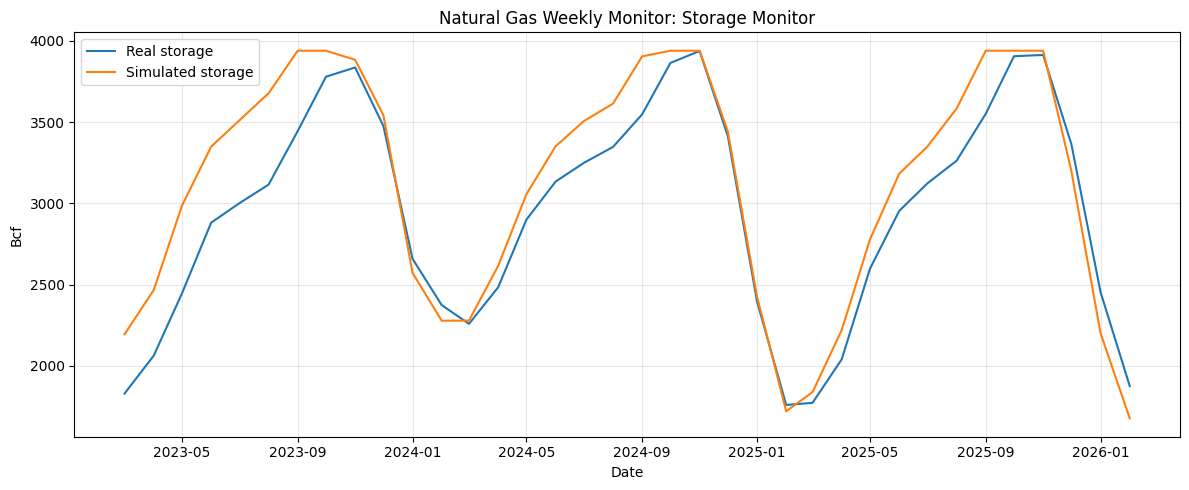

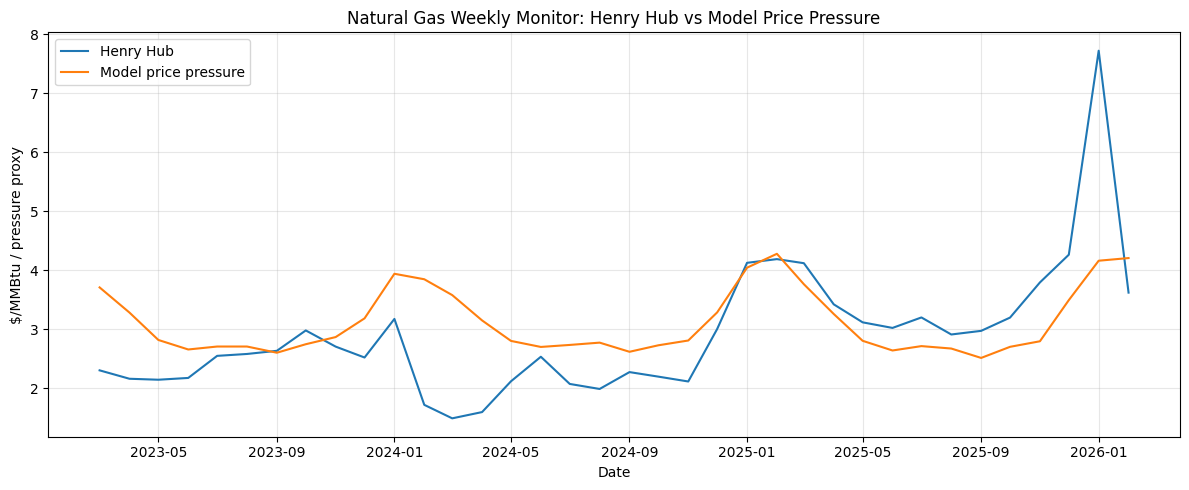

In [14]:
def plot_storage_monitor(report_df):
    plt.figure(figsize=(12, 5))
    plt.plot(report_df["date"], report_df["storage_real"], label="Real storage")
    plt.plot(report_df["date"], report_df["storage_end_sim"], label="Simulated storage")
    plt.title(f"{REPORT_TITLE}: Storage Monitor")
    plt.xlabel("Date")
    plt.ylabel("Bcf")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_price_pressure_monitor(report_df):
    plt.figure(figsize=(12, 5))
    plt.plot(report_df["date"], report_df["price_real"], label="Henry Hub")
    plt.plot(report_df["date"], report_df["price_pressure_sim"], label="Model price pressure")
    plt.title(f"{REPORT_TITLE}: Henry Hub vs Model Price Pressure")
    plt.xlabel("Date")
    plt.ylabel("$/MMBtu / pressure proxy")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_storage_monitor(report_df)
plot_price_pressure_monitor(report_df)


## 11. Weekly chart pack — supply, demand, and balance

Use these diagnostics to explain *why* storage or price pressure is changing.


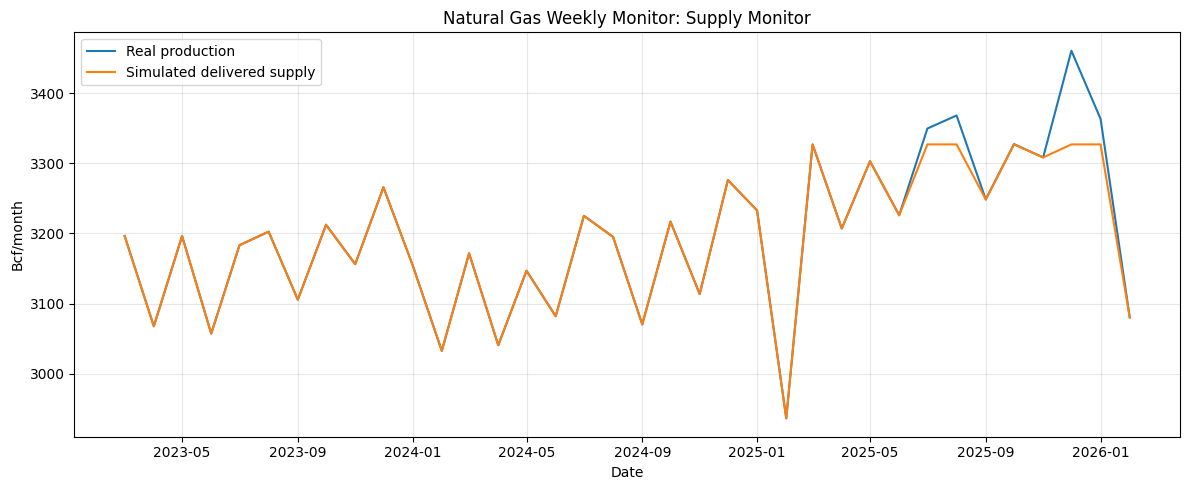

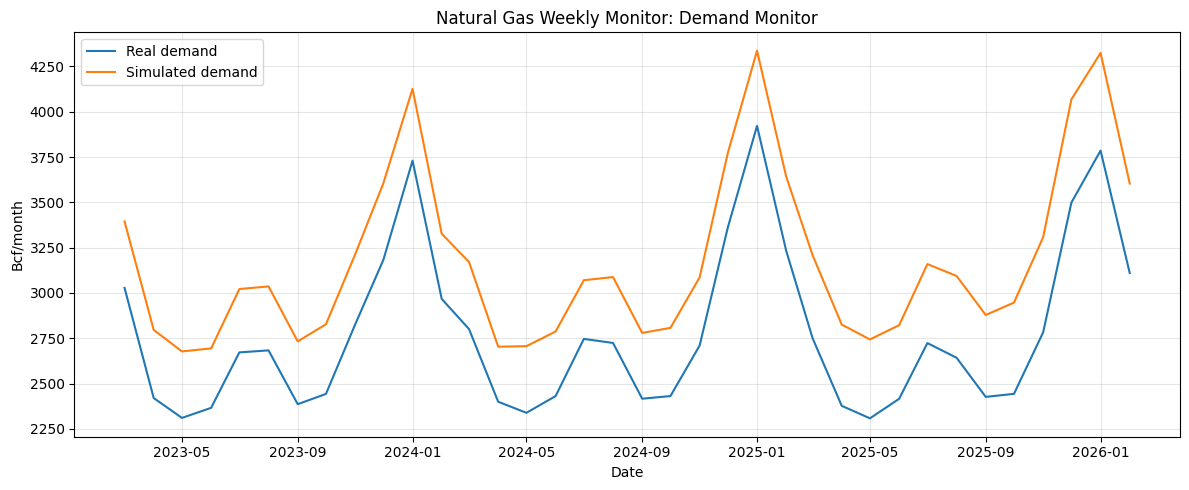

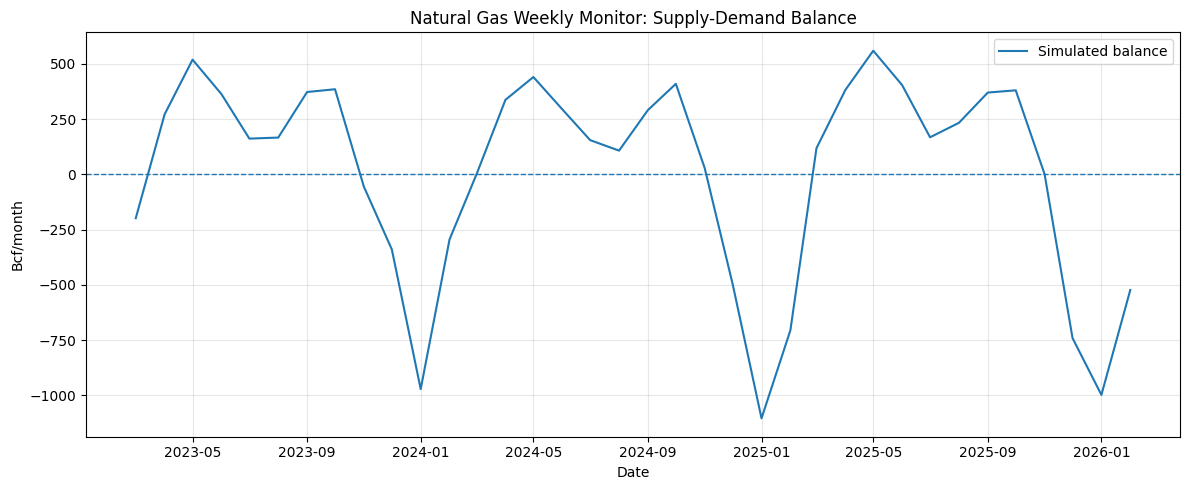

In [15]:
def plot_supply_demand_balance(report_df):
    plt.figure(figsize=(12, 5))
    plt.plot(report_df["date"], report_df["supply_real"], label="Real production")
    plt.plot(report_df["date"], report_df["delivered_supply_bcf"], label="Simulated delivered supply")
    plt.title(f"{REPORT_TITLE}: Supply Monitor")
    plt.xlabel("Date")
    plt.ylabel("Bcf/month")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 5))
    plt.plot(report_df["date"], report_df["demand_real"], label="Real demand")
    plt.plot(report_df["date"], report_df["demand_sim"], label="Simulated demand")
    plt.title(f"{REPORT_TITLE}: Demand Monitor")
    plt.xlabel("Date")
    plt.ylabel("Bcf/month")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 5))
    plt.plot(report_df["date"], report_df["balance_bcf"], label="Simulated balance")
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.title(f"{REPORT_TITLE}: Supply-Demand Balance")
    plt.xlabel("Date")
    plt.ylabel("Bcf/month")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_supply_demand_balance(report_df)


## 12. Pressure z-score and classification

This converts the pressure model into a reporting signal:

- Bullish / Bearish / Neutral
- Expected / Elevated / Extreme


In [16]:
def classify_pressure_z(z):
    if z >= 1.5:
        return "Extreme Bullish"
    if z >= 0.5:
        return "Bullish"
    if z <= -1.5:
        return "Extreme Bearish"
    if z <= -0.5:
        return "Bearish"
    return "Neutral"


def classify_extremeness(z):
    if abs(z) >= 1.5:
        return "Extreme"
    if abs(z) >= 0.5:
        return "Elevated"
    return "Expected"


def add_pressure_zscores(df, baseline=None, pressure_col="price_pressure_sim"):
    out = df.copy()
    if baseline is None:
        baseline = out[pressure_col]
    mu = float(pd.to_numeric(baseline, errors="coerce").mean())
    sigma = float(pd.to_numeric(baseline, errors="coerce").std(ddof=1))
    if sigma == 0 or not np.isfinite(sigma):
        sigma = 1.0
    out["pressure_z"] = (out[pressure_col] - mu) / sigma
    out["pressure_signal"] = out["pressure_z"].apply(classify_pressure_z)
    out["pressure_extremeness"] = out["pressure_z"].apply(classify_extremeness)
    return out

best_comparison = add_pressure_zscores(best_comparison, baseline=best_comparison["price_pressure_sim"])
report_df = get_recent_window(best_comparison, months=REPORT_LOOKBACK_MONTHS)

report_df[["date", "price_real", "price_pressure_sim", "pressure_z", "pressure_signal", "pressure_extremeness"]].tail(12)


,date,price_real,price_pressure_sim,pressure_z,pressure_signal,pressure_extremeness
86,2025-03-01,4.120000,3.764,0.930466,Bullish,Elevated
87,2025-04-01,3.423333,3.260,0.053815,Neutral,Expected
88,2025-05-01,3.118571,2.806,-0.735868,Bearish,Elevated
89,2025-06-01,3.024000,2.642,-1.021127,Bearish,Elevated
90,2025-07-01,3.201364,2.716,-0.892413,Bearish,Elevated
91,2025-08-01,2.912857,2.675,-0.963727,Bearish,Elevated
92,2025-09-01,2.974286,2.516,-1.240290,Bearish,Elevated
93,2025-10-01,3.199091,2.704,-0.913285,Bearish,Elevated
94,2025-11-01,3.794118,2.798,-0.749783,Bearish,Elevated
95,2025-12-01,4.263810,3.495,0.462571,Neutral,Expected


## 13. Next-quarter Monte Carlo forecast

The forward view now uses Monte Carlo simulation.

For each scenario, the notebook reports:
- Expected path
- Min / max path
- 10th / 90th percentile range

Use these outputs to frame next-quarter trend direction and whether conditions look expected, elevated, or extreme.


In [17]:
latest_storage = float(monthly_df["storage_bcf"].iloc[-1])

forward_scenarios = {
    "Base 3M": make_forward_scenario(base_scenario, initial_storage=latest_storage, **BASE_FORWARD),
    "Cold + LNG 3M": make_forward_scenario(base_scenario, initial_storage=latest_storage, **COLD_LNG_FORWARD),
    "Loose Supply 3M": make_forward_scenario(base_scenario, initial_storage=latest_storage, **LOOSE_SUPPLY_FORWARD),
}

# Apply tuned pressure parameters from the historical grid search to each forward scenario.
for s in forward_scenarios.values():
    s["storage_price_sensitivity"] = best["storage_price_sensitivity"]
    s["storage_change_price_sensitivity"] = best["storage_change_price_sensitivity"]
    s["price_inertia"] = best["price_inertia"]


def simulate_weather_paths(weather_df, start_date, months=3, n=500, seed=42, method="bootstrap", std_multiplier=1.5):
    """
    Generate future monthly HDD/CDD paths.

    Uses month-of-year sampling so a Jan forecast samples historical Januaries,
    a Feb forecast samples historical Februaries, etc. This preserves gas-relevant
    weather seasonality better than sampling from all months together.
    """
    rng = np.random.default_rng(seed)

    hist = weather_df.copy()
    hist.index = pd.to_datetime(hist.index)
    hist = hist.dropna(subset=["hdd", "cdd"]).sort_index()

    start_date = pd.to_datetime(start_date)
    future_dates = pd.date_range(start_date, periods=months, freq="MS")

    paths = []
    for sim in range(n):
        rows = []
        for dt in future_dates:
            same_month = hist.loc[hist.index.month == dt.month]
            if same_month.empty:
                same_month = hist

            if method == "bootstrap":
                sampled = same_month.sample(n=1, replace=True, random_state=int(rng.integers(0, 2**31 - 1))).iloc[0]
                hdd = float(sampled["hdd"])
                cdd = float(sampled["cdd"])
            else:
                hdd_std = float(same_month["hdd"].std(ddof=1))
                cdd_std = float(same_month["cdd"].std(ddof=1))
                if not np.isfinite(hdd_std):
                    hdd_std = 0.0
                if not np.isfinite(cdd_std):
                    cdd_std = 0.0
                hdd = float(rng.normal(same_month["hdd"].mean(), hdd_std * std_multiplier))
                cdd = float(rng.normal(same_month["cdd"].mean(), cdd_std * std_multiplier))
                hdd = max(0.0, hdd)
                cdd = max(0.0, cdd)

            rows.append({"date": dt, "hdd": hdd, "cdd": cdd})

        paths.append(pd.DataFrame(rows))

    return paths


def run_monte_carlo_scenario(name, scenario, weather_paths, months=3, seed=42):
    """Run MC by injecting each generated HDD/CDD path into the simulator."""
    paths = []

    for i, weather_path in enumerate(weather_paths):
        future_panel = weather_path.copy().reset_index(drop=True)

        # Required drivers used by GasMarket.supply() and demand().
        # Do NOT include demand_bcf here; we want demand() to use HDD/CDD.
        rng = np.random.default_rng(seed + i)
        supply_noise_std = float(scenario.get("supply_noise_pct", 0.0)) * float(scenario["base_supply"])
        if supply_noise_std > 0:
            future_panel["production_bcf"] = rng.normal(float(scenario["base_supply"]), supply_noise_std, len(future_panel))
        else:
            future_panel["production_bcf"] = float(scenario["base_supply"])

        future_panel["lng_exports_bcf"] = float(scenario["lng_exports"])

        s = scenario.copy()
        s["use_historical_drivers"] = True
        s["use_weather_demand"] = True
        s["historical_panel"] = future_panel

        # Optional residual noise around HDD/CDD-estimated demand.
        s.setdefault("demand_noise_std", 50.0)

        df = run_scenario(name, s, months=months, seed=seed + i)
        df["simulation"] = i
        paths.append(df)

    return pd.concat(paths, ignore_index=True)


# Forecast starts at the first month after the latest historical EIA month.
forecast_start = (pd.to_datetime(monthly_df.index.max()) + pd.offsets.MonthBegin(1)).normalize()

weather_paths = simulate_weather_paths(
    weather_df,
    start_date=forecast_start,
    months=FORECAST_MONTHS,
    n=N_MONTE_CARLO,
    seed=MC_SEED,
    method="bootstrap",  # use "normal" for Gaussian month-specific draws
)

forward_mc_results = pd.concat([
    run_monte_carlo_scenario(name, scenario, weather_paths, months=FORECAST_MONTHS, seed=MC_SEED)
    for name, scenario in forward_scenarios.items()
], ignore_index=True)

print("Storage dispersion check:")
print(forward_mc_results.groupby(["scenario", "month"])["storage_bcf"].std().unstack(0))

forward_mc_results.head()


Storage dispersion check:
scenario    Base 3M  Cold + LNG 3M  Loose Supply 3M
month                                              
1         49.022155      49.021693        49.021512
2         69.301681      69.299175        69.302952
3         89.265209      89.264858        89.265156


,month,price,raw_supply_bcf,delivered_supply_bcf,demand_bcf,balance_bcf,storage_start_bcf,storage_bcf,storage_change_bcf,storage_ratio,pipeline_capacity_bcf,lng_exports_bcf,scenario,simulation
0,1,3.387,2963.1,2963.1,2972.0,-8.9,1876.0,1867.1,-8.9,0.474,3326.9329,285.411051,Base 3M,0
1,2,3.383,2963.1,2963.1,2940.2,22.9,1867.1,1890.0,22.9,0.480,3326.9329,285.411051,Base 3M,0
2,3,3.412,2963.1,2963.1,2979.5,-16.4,1890.0,1873.6,-16.4,0.476,3326.9329,285.411051,Base 3M,0
3,1,3.377,2963.1,2963.1,2960.0,3.1,1876.0,1879.1,3.1,0.477,3326.9329,285.411051,Base 3M,1
4,2,3.342,2963.1,2963.1,2901.7,61.4,1879.1,1940.5,61.4,0.493,3326.9329,285.411051,Base 3M,1


## 14. Monte Carlo expected, min, max summary

This is the table to use for the next-quarter report.


In [18]:
def summarize_monte_carlo(mc_df):
    summary = (
        mc_df
        .groupby(["scenario", "month"], as_index=False)
        .agg(
            expected_price_pressure=("price", "mean"),
            min_price_pressure=("price", "min"),
            max_price_pressure=("price", "max"),
            p10_price_pressure=("price", lambda x: x.quantile(0.10)),
            p90_price_pressure=("price", lambda x: x.quantile(0.90)),

            expected_storage_bcf=("storage_bcf", "mean"),
            min_storage_bcf=("storage_bcf", "min"),
            max_storage_bcf=("storage_bcf", "max"),
            p10_storage_bcf=("storage_bcf", lambda x: x.quantile(0.10)),
            p90_storage_bcf=("storage_bcf", lambda x: x.quantile(0.90)),

            expected_storage_change_bcf=("storage_change_bcf", "mean"),
            min_storage_change_bcf=("storage_change_bcf", "min"),
            max_storage_change_bcf=("storage_change_bcf", "max"),

            expected_balance_bcf=("balance_bcf", "mean"),
            min_balance_bcf=("balance_bcf", "min"),
            max_balance_bcf=("balance_bcf", "max"),
        )
    )

    for col in summary.columns:
        if col != "scenario":
            summary[col] = pd.to_numeric(summary[col], errors="coerce")
    return summary


forward_mc_summary = summarize_monte_carlo(forward_mc_results)

# Display rounded copy only; keep full precision in forward_mc_summary for plots/signals.
forward_mc_summary.round(2)


,scenario,month,expected_price_pressure,min_price_pressure,max_price_pressure,p10_price_pressure,p90_price_pressure,expected_storage_bcf,min_storage_bcf,max_storage_bcf,p10_storage_bcf,p90_storage_bcf,expected_storage_change_bcf,min_storage_change_bcf,max_storage_change_bcf,expected_balance_bcf,min_balance_bcf,max_balance_bcf
0,Base 3M,1,3.36,3.22,3.50,3.31,3.42,1893.49,1733.6,2057.8,1828.39,1958.88,17.49,-142.4,181.8,17.49,-142.4,181.8
1,Base 3M,2,3.38,3.24,3.52,3.31,3.44,1907.70,1702.1,2100.3,1816.98,1995.40,14.20,-116.3,170.6,14.20,-116.3,170.6
2,Base 3M,3,3.38,3.23,3.63,3.30,3.46,1921.37,1590.3,2145.8,1811.89,2035.80,13.67,-209.8,160.1,13.67,-209.8,160.1
3,Cold + LNG 3M,1,3.64,3.49,3.78,3.58,3.70,1580.94,1421.1,1745.2,1515.79,1646.29,-295.06,-454.9,-130.8,-295.06,-454.9,-130.8
4,Cold + LNG 3M,2,3.83,3.69,3.97,3.76,3.89,1282.58,1077.0,1475.2,1191.88,1370.30,-298.36,-428.8,-142.0,-298.36,-428.8,-142.0
5,Cold + LNG 3M,3,3.96,3.80,4.21,3.88,4.04,983.70,652.6,1208.1,874.19,1098.10,-298.88,-522.4,-152.4,-298.88,-522.4,-152.4
6,Loose Supply 3M,1,3.17,3.02,3.31,3.11,3.22,2117.26,1957.4,2281.5,2052.18,2182.59,241.26,81.4,405.5,241.26,81.4,405.5
7,Loose Supply 3M,2,3.05,2.92,3.20,2.99,3.12,2355.23,2149.6,2547.9,2264.57,2442.90,237.97,107.5,394.3,237.97,107.5,394.3
8,Loose Supply 3M,3,2.97,2.81,3.21,2.89,3.04,2592.67,2261.6,2817.1,2483.19,2707.10,237.44,13.9,383.9,237.44,13.9,383.9


## 15. Next-quarter Monte Carlo charts

Use the expected line as the base case and the min/max or 10–90% band to show uncertainty.


Base 3M storage forecast distribution:


,month,min_storage_bcf,p10_storage_bcf,expected_storage_bcf,p90_storage_bcf,max_storage_bcf
0,1,1733.6,1828.4,1893.5,1958.9,2057.8
1,2,1702.1,1817.0,1907.7,1995.4,2100.3
2,3,1590.3,1811.9,1921.4,2035.8,2145.8


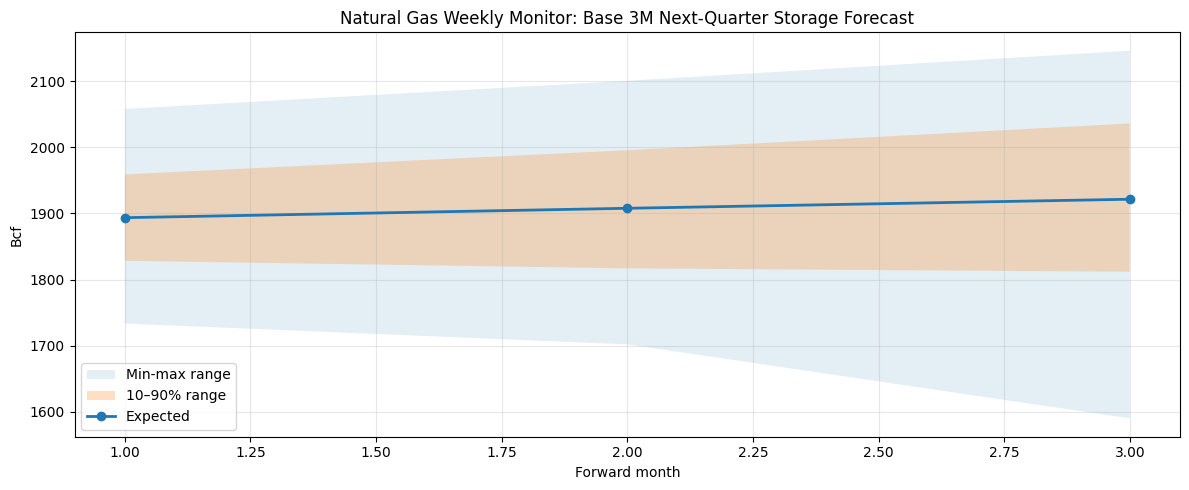

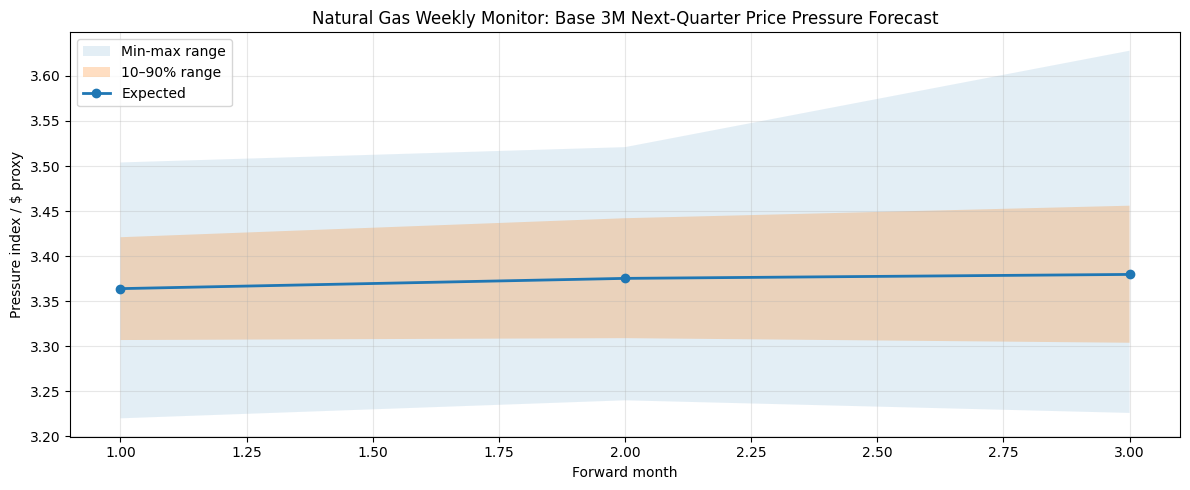

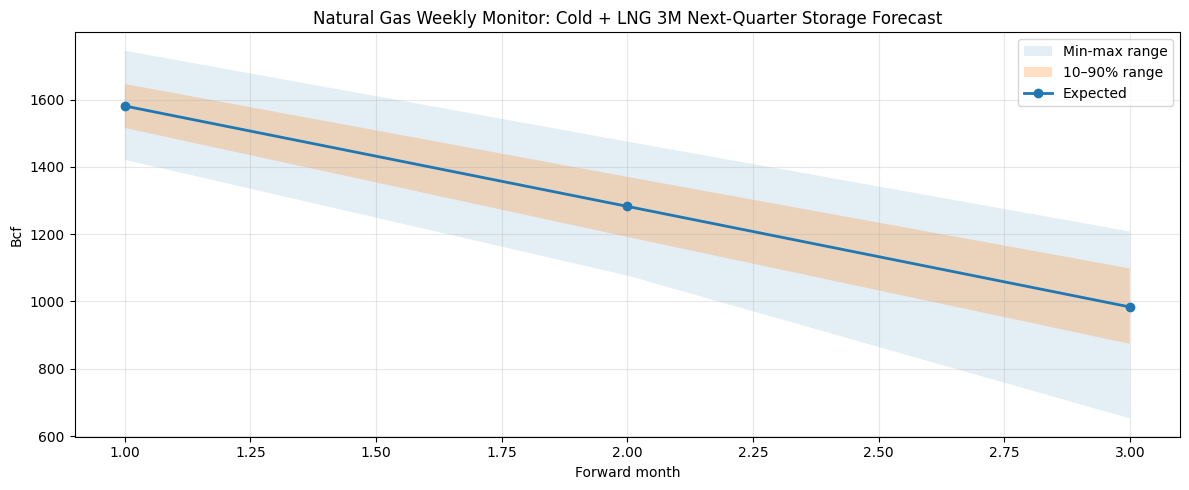

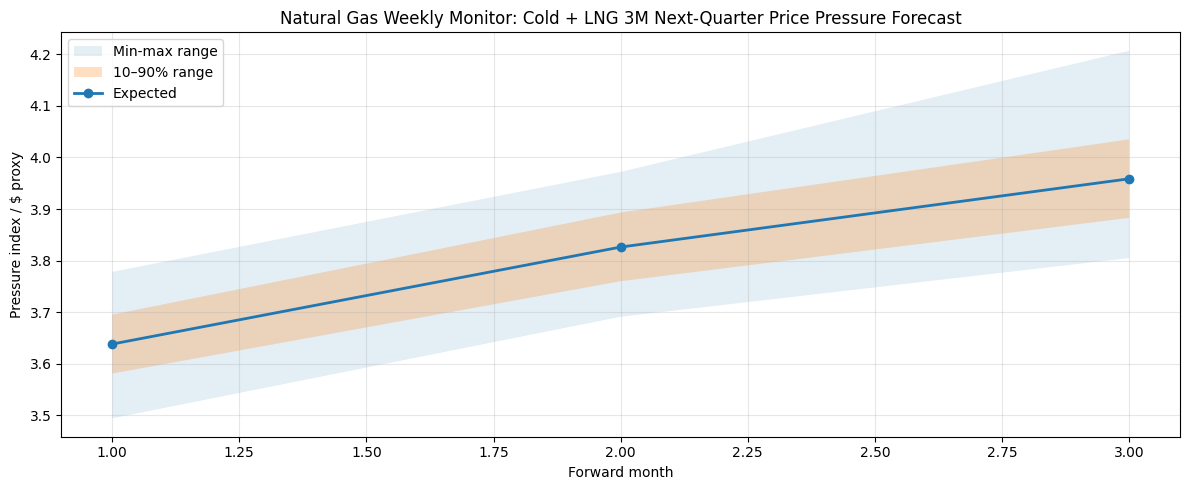

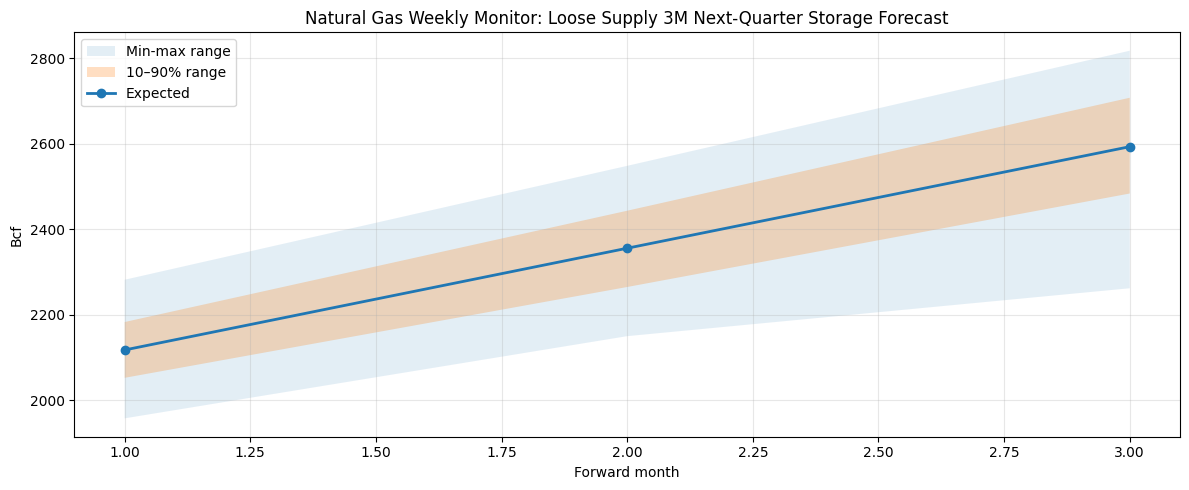

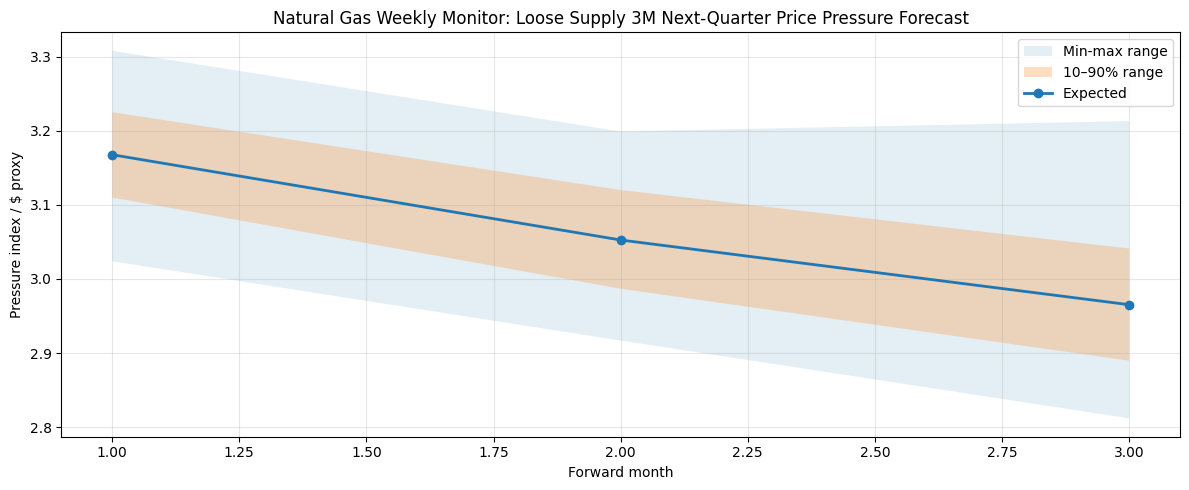

In [19]:
def plot_mc_band(summary, scenario, value_prefix, ylabel, title):
    g = summary.loc[summary["scenario"] == scenario].copy().sort_values("month")
    if g.empty:
        raise ValueError(f"No Monte Carlo summary rows found for scenario={scenario!r}")

    x = g["month"].astype(float).to_numpy()
    expected = g[f"expected_{value_prefix}"].astype(float).to_numpy()
    p10 = g[f"p10_{value_prefix}"].astype(float).to_numpy()
    p90 = g[f"p90_{value_prefix}"].astype(float).to_numpy()
    vmin = g[f"min_{value_prefix}"].astype(float).to_numpy()
    vmax = g[f"max_{value_prefix}"].astype(float).to_numpy()

    plt.figure(figsize=(12, 5))
    plt.fill_between(x, vmin, vmax, alpha=0.12, label="Min-max range")
    plt.fill_between(x, p10, p90, alpha=0.25, label="10–90% range")
    plt.plot(x, expected, marker="o", linewidth=2, label="Expected")
    plt.title(title)
    plt.xlabel("Forward month")
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# Quick diagnostic: if p10=p90 and min=max, weather is not affecting outcomes.
print("Base 3M storage forecast distribution:")
display(
    forward_mc_summary.loc[forward_mc_summary["scenario"] == "Base 3M", [
        "month", "min_storage_bcf", "p10_storage_bcf", "expected_storage_bcf", "p90_storage_bcf", "max_storage_bcf"
    ]].round(1)
)

for scenario in forward_mc_summary["scenario"].unique():
    plot_mc_band(
        forward_mc_summary,
        scenario,
        value_prefix="storage_bcf",
        ylabel="Bcf",
        title=f"{REPORT_TITLE}: {scenario} Next-Quarter Storage Forecast",
    )

    plot_mc_band(
        forward_mc_summary,
        scenario,
        value_prefix="price_pressure",
        ylabel="Pressure index / $ proxy",
        title=f"{REPORT_TITLE}: {scenario} Next-Quarter Price Pressure Forecast",
    )


## 16. Forward signal table

This converts Monte Carlo output into an Energy Atlas-style signal.

The signal uses expected pressure, expected storage change, and uncertainty range.


In [20]:
def _classify_storage_trend(total_storage_change_bcf):
    if total_storage_change_bcf <= -500:
        return "Tightening sharply"
    if total_storage_change_bcf <= -150:
        return "Tightening"
    if total_storage_change_bcf >= 500:
        return "Loosening sharply"
    if total_storage_change_bcf >= 150:
        return "Loosening"
    return "Balanced"


def _direction_from_storage(total_storage_change_bcf):
    if total_storage_change_bcf < -150:
        return "Bullish"
    if total_storage_change_bcf > 150:
        return "Bearish"
    return "Neutral"


def _confidence_score(pressure_z, storage_direction, pressure_label, uncertainty_width):
    z_component = min(abs(pressure_z) / 2.0, 1.0)
    pressure_direction = (
        "Bullish" if "Bullish" in pressure_label
        else "Bearish" if "Bearish" in pressure_label
        else "Neutral"
    )
    agreement_component = 1.0 if storage_direction == pressure_direction or pressure_direction == "Neutral" else 0.5
    uncertainty_component = max(0.0, 1.0 - min(uncertainty_width / 4.0, 1.0))
    return round(0.30 + 0.35 * z_component + 0.20 * agreement_component + 0.15 * uncertainty_component, 2)


def build_mc_forward_signal(summary, historical_pressure):
    hist_mean = float(historical_pressure.mean())
    hist_std = float(historical_pressure.std(ddof=1))
    if hist_std == 0 or not np.isfinite(hist_std):
        hist_std = 1.0

    signals = []
    for scenario, g in summary.groupby("scenario"):
        g = g.sort_values("month")

        avg_expected_pressure = float(g["expected_price_pressure"].mean())
        ending_expected_pressure = float(g["expected_price_pressure"].iloc[-1])
        pressure_z = (avg_expected_pressure - hist_mean) / hist_std

        pressure_label = classify_pressure_z(pressure_z)
        extremeness = classify_extremeness(pressure_z)

        total_expected_storage_change = float(g["expected_storage_change_bcf"].sum())
        storage_trend = _classify_storage_trend(total_expected_storage_change)
        storage_direction = _direction_from_storage(total_expected_storage_change)

        ending_expected_storage = float(g["expected_storage_bcf"].iloc[-1])
        ending_min_storage = float(g["min_storage_bcf"].iloc[-1])
        ending_max_storage = float(g["max_storage_bcf"].iloc[-1])

        pressure_uncertainty_width = float((g["p90_price_pressure"] - g["p10_price_pressure"]).mean())
        confidence = _confidence_score(pressure_z, storage_direction, pressure_label, pressure_uncertainty_width)

        signals.append({
            "scenario": scenario,
            "horizon_months": int(g["month"].max()),
            "price_pressure": pressure_label,
            "extremeness": extremeness,
            "pressure_z": round(pressure_z, 2),
            "expected_avg_pressure": round(avg_expected_pressure, 2),
            "expected_ending_pressure": round(ending_expected_pressure, 2),
            "p10_ending_pressure": round(float(g["p10_price_pressure"].iloc[-1]), 2),
            "p90_ending_pressure": round(float(g["p90_price_pressure"].iloc[-1]), 2),
            "storage_trend": storage_trend,
            "expected_storage_change_bcf": round(total_expected_storage_change, 1),
            "expected_ending_storage_bcf": round(ending_expected_storage, 1),
            "min_ending_storage_bcf": round(ending_min_storage, 1),
            "max_ending_storage_bcf": round(ending_max_storage, 1),
            "confidence": confidence,
        })

    return pd.DataFrame(signals).sort_values(["pressure_z"], ascending=False)


historical_pressure = pd.to_numeric(best_comparison["price_pressure_sim"], errors="coerce").dropna()
forward_signals = build_mc_forward_signal(forward_mc_summary, historical_pressure)
forward_signals


,scenario,horizon_months,price_pressure,extremeness,pressure_z,expected_avg_pressure,expected_ending_pressure,p10_ending_pressure,p90_ending_pressure,storage_trend,expected_storage_change_bcf,expected_ending_storage_bcf,min_ending_storage_bcf,max_ending_storage_bcf,confidence
1,Cold + LNG 3M,3,Bullish,Elevated,1.01,3.81,3.96,3.88,4.04,Tightening sharply,-892.3,983.7,652.6,1208.1,0.82
0,Base 3M,3,Neutral,Expected,0.25,3.37,3.38,3.30,3.46,Balanced,45.4,1921.4,1590.3,2145.8,0.69
2,Loose Supply 3M,3,Neutral,Expected,-0.29,3.06,2.97,2.89,3.04,Loosening sharply,716.7,2592.7,2261.6,2817.1,0.70


## 17. Weekly report summary

This cell prints a draft text block you can use for Energy Atlas, Twitter/X, or Substack.


In [21]:
def format_energy_atlas_signal(signal):
    return (
        f"{signal['scenario']} ({signal['horizon_months']}M): "
        f"{signal['price_pressure']} pressure, {signal['extremeness'].lower()} conditions. "
        f"Expected storage path is {signal['storage_trend'].lower()} "
        f"({signal['expected_storage_change_bcf']} Bcf over the horizon). "
        f"Expected ending storage: {signal['expected_ending_storage_bcf']} Bcf "
        f"(min-max: {signal['min_ending_storage_bcf']}–{signal['max_ending_storage_bcf']} Bcf). "
        f"Confidence: {signal['confidence']:.2f}."
    )


latest = report_df.iloc[-1]
prior = report_df.iloc[-2] if len(report_df) > 1 else latest

print(f"# {REPORT_TITLE} — {REPORT_DATE.date()}")
print()
print("## Current market read")
print(
    f"Model pressure is {latest['pressure_signal']} "
    f"with a pressure z-score of {latest['pressure_z']:.2f}. "
    f"Latest storage is {latest['storage_real']:,.0f} Bcf. "
    f"The latest monthly storage change was {latest['storage_change_real']:,.0f} Bcf."
)

print()
print("## Next-quarter Monte Carlo scenarios")
for row in forward_signals.to_dict("records"):
    print("- " + format_energy_atlas_signal(row))

print()
print("## Suggested framing")
print(
    "The model should be interpreted as a directional pressure monitor, not an exact Henry Hub forecast. "
    "The key question is whether storage and balance conditions point to tightening, loosening, or normal seasonal behavior over the next quarter."
)


# Natural Gas Weekly Monitor — 2026-05-06

## Current market read
Model pressure is Extreme Bullish with a pressure z-score of 1.70. Latest storage is 1,876 Bcf. The latest monthly storage change was -578 Bcf.

## Next-quarter Monte Carlo scenarios
- Cold + LNG 3M (3M): Bullish pressure, elevated conditions. Expected storage path is tightening sharply (-892.3 Bcf over the horizon). Expected ending storage: 983.7 Bcf (min-max: 652.6–1208.1 Bcf). Confidence: 0.82.
- Base 3M (3M): Neutral pressure, expected conditions. Expected storage path is balanced (45.4 Bcf over the horizon). Expected ending storage: 1921.4 Bcf (min-max: 1590.3–2145.8 Bcf). Confidence: 0.69.
- Loose Supply 3M (3M): Neutral pressure, expected conditions. Expected storage path is loosening sharply (716.7 Bcf over the horizon). Expected ending storage: 2592.7 Bcf (min-max: 2261.6–2817.1 Bcf). Confidence: 0.70.

## Suggested framing
The model should be interpreted as a directional pressure monitor, not an exact Henry Hub

## 18. Optional export

Set `EXPORT = True` if you want CSV outputs for charting or uploading elsewhere.


In [22]:
EXPORT = False

if EXPORT:
    report_df.to_csv("energy_atlas_weekly_monitor_history.csv", index=False)
    forward_mc_results.to_csv("energy_atlas_forward_monte_carlo_paths.csv", index=False)
    forward_mc_summary.to_csv("energy_atlas_forward_monte_carlo_summary.csv", index=False)
    forward_signals.to_csv("energy_atlas_forward_signals.csv", index=False)
    print("Exported weekly monitor and forward Monte Carlo CSV files.")
